# PCA — Spotify & Yelp





In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

PROCESSED = r"C:\Users\ryanm\Documents\coding_projects\restaurant_recommendation\data\processed"

spotify = pd.read_csv(os.path.join(PROCESSED, 'tracks_features_clean.csv'))
yelp    = pd.read_csv(os.path.join(PROCESSED, 'yelp_ml_ready.csv'))

print(f"Spotify: {spotify.shape}")
print(f"Yelp:    {yelp.shape}")

Spotify: (1201245, 24)
Yelp:    (52268, 27)


---
## Part 1 — Spotify

### Step 1 — Select features

Keep only continuous audio features,  Drop (categorical/binary).

In [ ]:
AUDIO_FEATURES = [
    'danceability', 'energy', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'loudness', 'tempo'
]

df_spotify = spotify[AUDIO_FEATURES].copy()
print(f"Shape: {df_spotify.shape}")

Shape: (1201245, 9)


,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,loudness,tempo
count,1201245.000,1201245.000,1201245.000,1201245.000,1201245.000,1201245.000,1201245.000,1201245.000,1201245.000
mean,0.494,0.510,0.085,0.447,0.283,0.202,0.429,-11.785,117.906
std,0.188,0.294,0.116,0.385,0.376,0.180,0.270,6.935,30.451
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-58.925,30.018
25%,0.357,0.253,0.035,0.038,0.000,0.097,0.193,-15.223,94.222
50%,0.501,0.524,0.045,0.388,0.008,0.125,0.404,-9.779,116.872
75%,0.633,0.767,0.072,0.861,0.718,0.245,0.645,-6.713,137.108
max,1.000,1.000,0.969,0.996,1.000,1.000,1.000,7.234,248.934


### Step 2 — Check distributions

Outliers will pull the principal components toward them rather than true patterns as they are weighted heavily.

Skew per feature:
speechiness         4.24
liveness            2.27
instrumentalness    0.80
tempo               0.40
valence             0.26
acousticness        0.16
danceability       -0.08
energy             -0.09
loudness           -1.23
dtype: float64


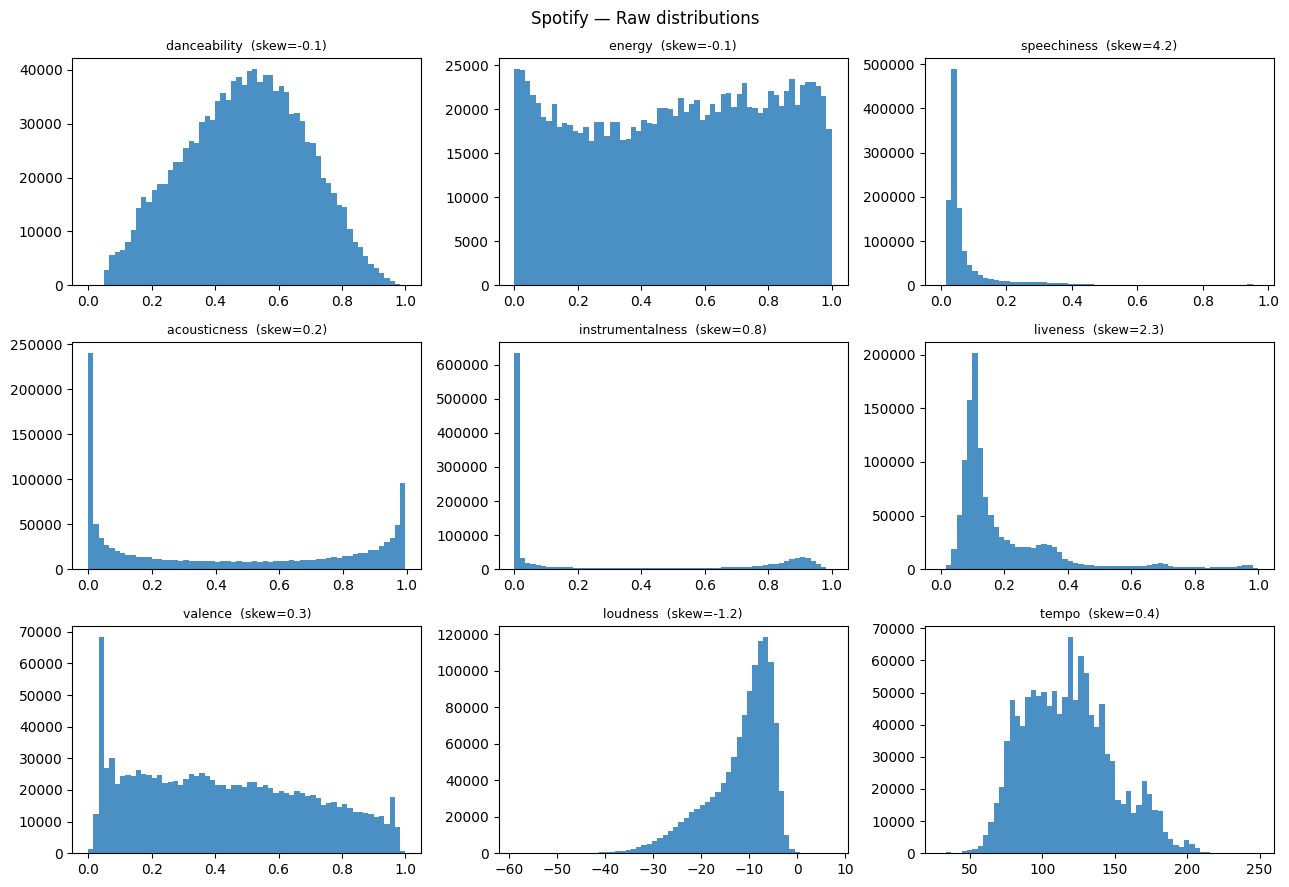

In [ ]:
skews = df_spotify.skew().sort_values(ascending=False)
print("Skew per feature:")
print(skews.round(2))

### Step 3 — Apply log1p to skewed features

`log1p` compresses the long tail without breaking zero values. Applied to features with skew > 1.

In [4]:
SKEWED = ['instrumentalness', 'acousticness', 'speechiness', 'liveness']

df_spotify[SKEWED] = df_spotify[SKEWED].apply(np.log1p)

print("Skew after log1p:")
print(df_spotify[SKEWED].skew().round(2))

Skew after log1p:
instrumentalness    0.72
acousticness        0.03
speechiness         3.54
liveness            1.89
dtype: float64


### Step 4 — Standardize

StandardScaler brings every feature to mean=0, std=1. We need it because loudness is in different unit measure.

In [5]:
scaler_s = StandardScaler()
X_scaled = scaler_s.fit_transform(df_spotify)

print(f"Scaled matrix: {X_scaled.shape}")

Scaled matrix: (1201245, 9)


### Step 5 — Fit PCA & pick number of components

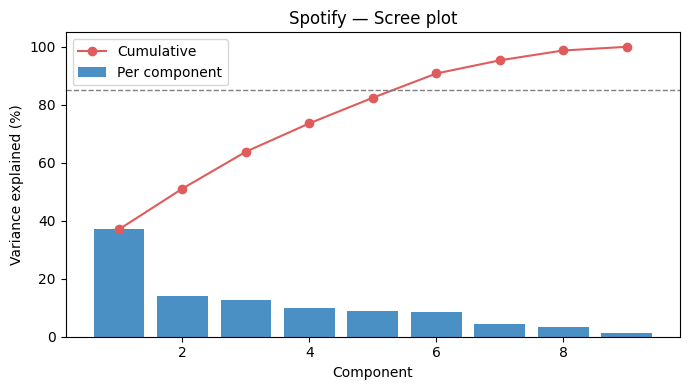

  1 components → 37.0% variance
  2 components → 51.1% variance
  3 components → 63.8% variance
  4 components → 73.6% variance
  5 components → 82.4% variance
  6 components → 90.8% variance
  7 components → 95.3% variance
  8 components → 98.7% variance
  9 components → 100.0% variance


In [ ]:
pca_s = PCA()
pca_s.fit(X_scaled)

cumvar = np.cumsum(pca_s.explained_variance_ratio_)

for i, cv in enumerate(cumvar, 1):
    print(f" {i} components → {cv:.1%} variance")

In [7]:
K_SPOTIFY = int(np.argmax(cumvar >= 0.85)) + 1
print(f"Using {K_SPOTIFY} components ({cumvar[K_SPOTIFY-1]:.1%} variance retained)")

pca_s_final  = PCA(n_components=K_SPOTIFY)
song_pca_mat = pca_s_final.fit_transform(X_scaled)

print(f"song_pca_mat shape: {song_pca_mat.shape}")

Using 6 components (90.8% variance retained)
song_pca_mat shape: (1201245, 6)


### Step 6 — What does each component represent?

Each PC is a weighted combination of the original features. The loadings show which features drive each component — positive means the feature pushes the score up, negative means it pulls it down.

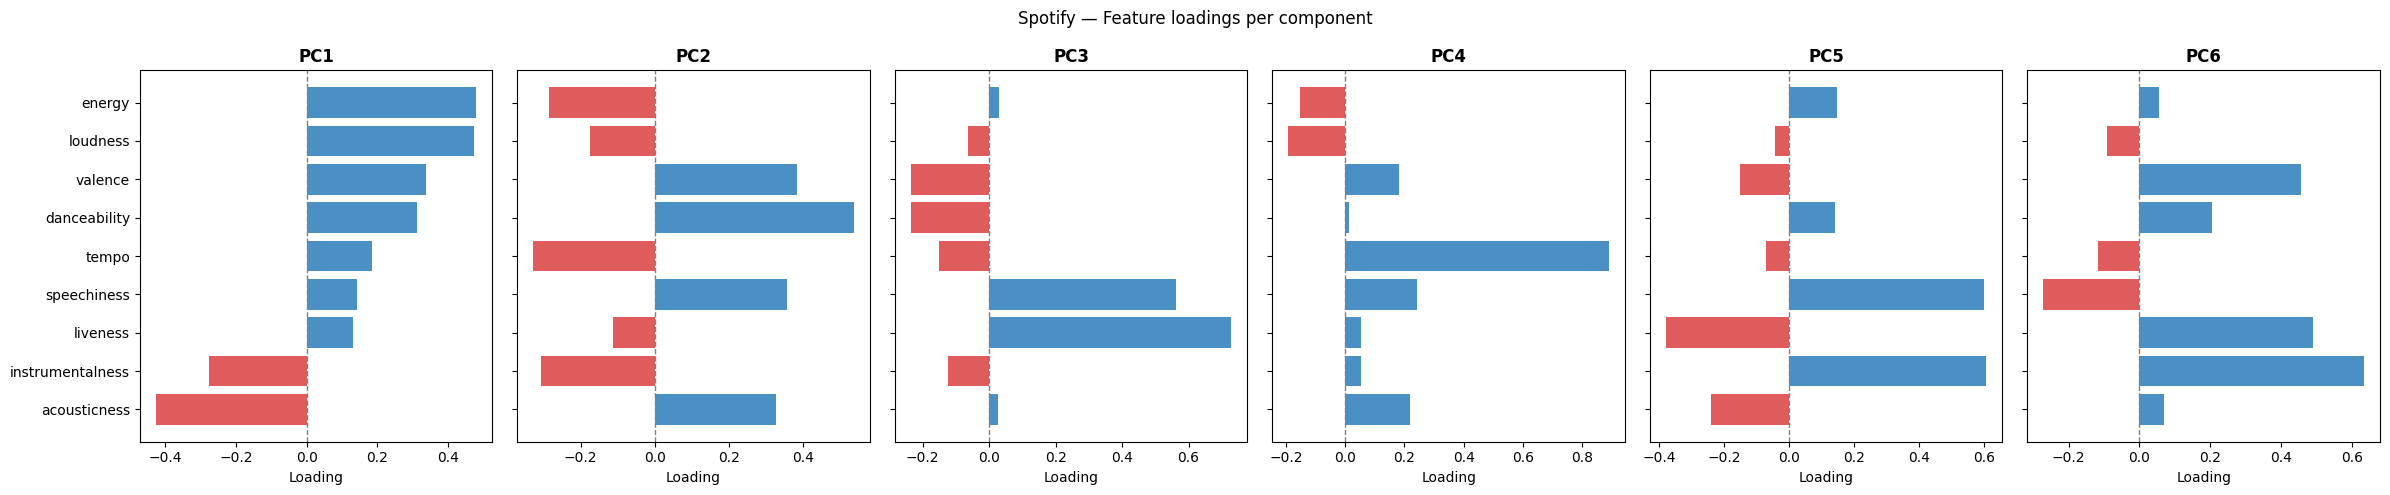

     danceability  energy  speechiness  acousticness  instrumentalness  liveness  valence  loudness  tempo
PC1          0.31    0.48         0.14         -0.43             -0.28      0.13     0.34      0.48   0.19
PC2          0.54   -0.29         0.36          0.33             -0.31     -0.11     0.39     -0.17  -0.33
PC3         -0.24    0.03         0.56          0.03             -0.12      0.73    -0.24     -0.06  -0.15
PC4          0.01   -0.15         0.24          0.22              0.05      0.05     0.18     -0.19   0.89
PC5          0.14    0.15         0.60         -0.24              0.61     -0.38    -0.15     -0.04  -0.07
PC6          0.20    0.06        -0.27          0.07              0.63      0.49     0.46     -0.09  -0.12


In [ ]:
loadings_s = pd.DataFrame(
    pca_s_final.components_,
    index=[f'PC{i+1}' for i in range(K_SPOTIFY)],
    columns=AUDIO_FEATURES
)

print(loadings_s.round(2).to_string())

---
## Part 2 — Yelp

### Step 1 — Select features

Keep continous columns only. Drop location, review count, and free-text fields.

In [ ]:
YELP_CANDIDATES = [
    'Ambience.romantic', 'Ambience.divey', 'Ambience.classy',
    'Ambience.hipster', 'Ambience.trendy', 'Ambience.upscale', 'Ambience.casual',
    'HasTV', 'HappyHour', 'RestaurantsGoodForGroups',
    'GoodForMeal.breakfast', 'GoodForMeal.brunch',
    'GoodForMeal.latenight', 'GoodForMeal.dinner',
    'RestaurantsTableService', 'NoiseLevel', 'stars'
]

YELP_FEATURES = [c for c in YELP_CANDIDATES if c in yelp.columns]

df_yelp = yelp[YELP_FEATURES].dropna().copy()
print(f"Shape after dropna: {df_yelp.shape}")

Using 17 features: ['Ambience.romantic', 'Ambience.divey', 'Ambience.classy', 'Ambience.hipster', 'Ambience.trendy', 'Ambience.upscale', 'Ambience.casual', 'HasTV', 'HappyHour', 'RestaurantsGoodForGroups', 'GoodForMeal.breakfast', 'GoodForMeal.brunch', 'GoodForMeal.latenight', 'GoodForMeal.dinner', 'RestaurantsTableService', 'NoiseLevel', 'stars']

Shape after dropna: (34808, 17)


### Step 2 — Drop near-constant columns

If almost every restaurant has the same value for a column (e.g. all zeros), it carries no signal for PCA.

In [10]:
variance = df_yelp.var()
low_var_cols = variance[variance < 0.01].index.tolist()

if low_var_cols:
    print(f"Dropping near-constant columns: {low_var_cols}")
    df_yelp = df_yelp.drop(columns=low_var_cols)
    YELP_FEATURES = df_yelp.columns.tolist()
else:
    print("No near-constant columns found.")

print(f"Final shape: {df_yelp.shape}")

No near-constant columns found.
Final shape: (34808, 17)


### Step 3 — Standardize

In [11]:
scaler_y = StandardScaler()
Y_scaled = scaler_y.fit_transform(df_yelp)

print(f"Scaled matrix: {Y_scaled.shape}")

Scaled matrix: (34808, 17)


### Step 4 — Fit PCA & pick number of components

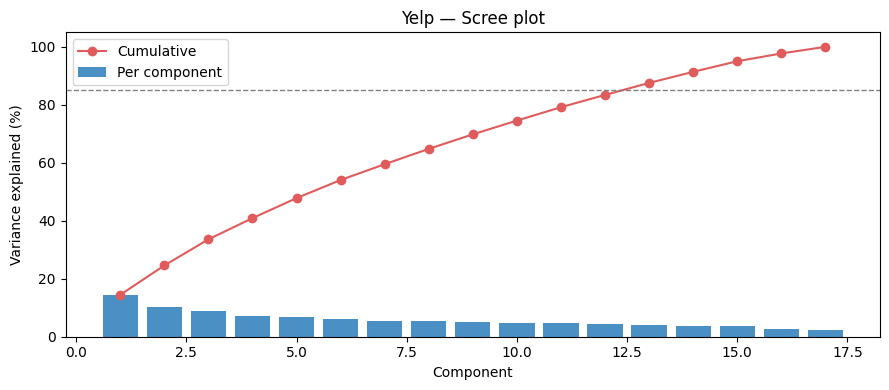

  1 components → 14.5% variance
  2 components → 24.6% variance
  3 components → 33.6% variance
  4 components → 40.9% variance
  5 components → 47.8% variance
  6 components → 54.1% variance
  7 components → 59.5% variance
  8 components → 64.8% variance
  9 components → 69.8% variance
  10 components → 74.6% variance
  11 components → 79.2% variance
  12 components → 83.4% variance
  13 components → 87.5% variance
  14 components → 91.4% variance
  15 components → 95.0% variance
  16 components → 97.7% variance
  17 components → 100.0% variance


In [ ]:
pca_y = PCA()
pca_y.fit(Y_scaled)

cumvar_y = np.cumsum(pca_y.explained_variance_ratio_)


for i, cv in enumerate(cumvar_y, 1):
    print(f"  {i} components → {cv:.1%} variance")

In [13]:
K_YELP = int(np.argmax(cumvar_y >= 0.85)) + 1
print(f"Using {K_YELP} components ({cumvar_y[K_YELP-1]:.1%} variance retained)")

pca_y_final      = PCA(n_components=K_YELP)
restaurant_pca_mat = pca_y_final.fit_transform(Y_scaled)

print(f"restaurant_pca_mat shape: {restaurant_pca_mat.shape}")

Using 13 components (87.5% variance retained)
restaurant_pca_mat shape: (34808, 13)


### Step 5 — What does each component represent?

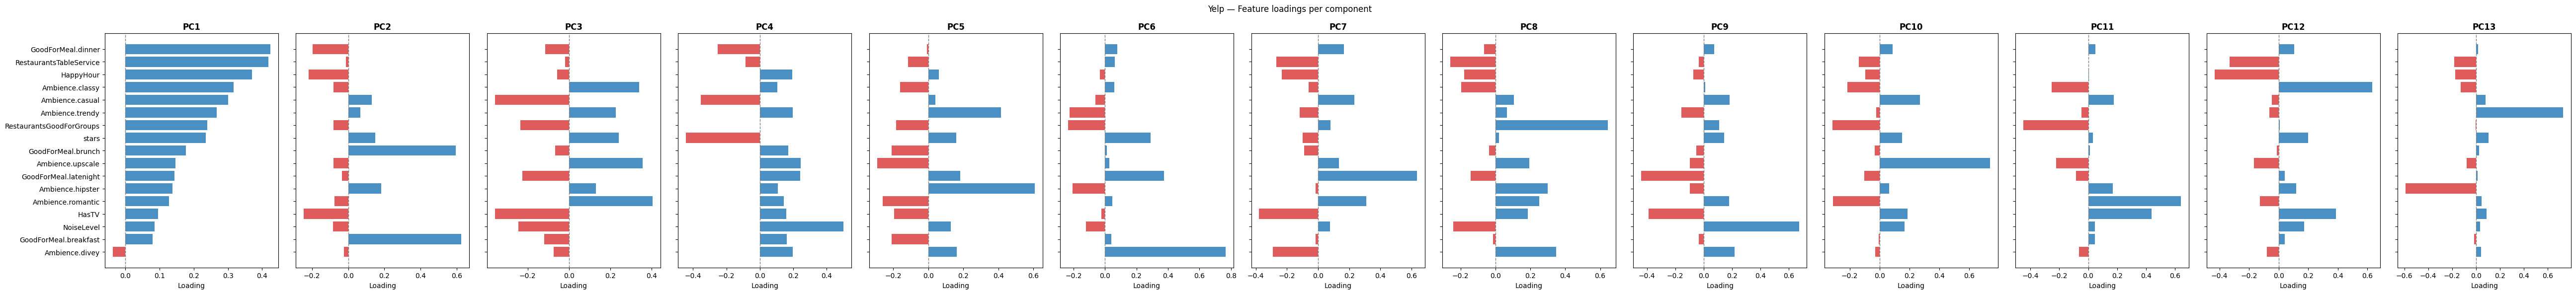

      Ambience.romantic  Ambience.divey  Ambience.classy  Ambience.hipster  Ambience.trendy  Ambience.upscale  Ambience.casual  HasTV  HappyHour  RestaurantsGoodForGroups  GoodForMeal.breakfast  GoodForMeal.brunch  GoodForMeal.latenight  GoodForMeal.dinner  RestaurantsTableService  NoiseLevel  stars
PC1                0.13           -0.04             0.32              0.14             0.27              0.15             0.30   0.10       0.37                      0.24                   0.08                0.18                   0.14                0.42                     0.42        0.09   0.24
PC2               -0.07           -0.02            -0.08              0.18             0.07             -0.08             0.13  -0.25      -0.22                     -0.08                   0.63                0.59                  -0.03               -0.20                    -0.01       -0.08   0.15
PC3                0.40           -0.07             0.34              0.13             0.23      

In [ ]:
loadings_y = pd.DataFrame(
    pca_y_final.components_,
    index=[f'PC{i+1}' for i in range(K_YELP)],
    columns=YELP_FEATURES
)

print(loadings_y.round(2).to_string())

---
## Part 3 — Save outputs for notebook 05

In [15]:
# Spotify — song PCA matrix + fitted objects
song_pca_df = pd.DataFrame(
    song_pca_mat,
    columns=[f'pc{i+1}' for i in range(K_SPOTIFY)]
)
song_pca_df.insert(0, 'id',      spotify['id'].values)
song_pca_df.insert(1, 'name',    spotify['name'].values)
song_pca_df.insert(2, 'artists', spotify['artists'].values)

song_pca_df.to_csv(os.path.join(PROCESSED, 'song_pca.csv'), index=False)
joblib.dump(scaler_s,    os.path.join(PROCESSED, 'spotify_scaler.pkl'))
joblib.dump(pca_s_final, os.path.join(PROCESSED, 'spotify_pca.pkl'))
print(f"song_pca.csv         {song_pca_df.shape}")

# Yelp — restaurant PCA matrix + fitted objects
restaurant_pca_df = pd.DataFrame(
    restaurant_pca_mat,
    columns=[f'pc{i+1}' for i in range(K_YELP)]
)
surviving_idx = df_yelp.index
if 'business_id' in yelp.columns:
    restaurant_pca_df.insert(0, 'business_id', yelp.loc[surviving_idx, 'business_id'].values)
if 'name' in yelp.columns:
    restaurant_pca_df.insert(1, 'name', yelp.loc[surviving_idx, 'name'].values)

restaurant_pca_df.to_csv(os.path.join(PROCESSED, 'restaurant_pca.csv'), index=False)
joblib.dump(scaler_y,    os.path.join(PROCESSED, 'yelp_scaler.pkl'))
joblib.dump(pca_y_final, os.path.join(PROCESSED, 'yelp_pca.pkl'))
print(f"restaurant_pca.csv   {restaurant_pca_df.shape}")

song_pca.csv         (1201245, 9)
restaurant_pca.csv   (34808, 15)
